# 03 - Classification ML sur Embeddings LLM (DistilBERT)

**SAE-117** — Epic 4 : ML Classique

## Objectif
Entraîner 4 algorithmes de ML classique sur les embeddings DistilBERT pré-calculés :
- Logistic Regression
- SVM (LinearSVC)
- Random Forest
- Naive Bayes (GaussianNB)

**Grille :** ML-LLM (1pt) + ML classiques plusieurs (4pts)

**Pré-requis :** SAE-112 (Extraction embeddings LLM DistilBERT)

## 1. Setup & Imports

In [1]:
import sys
sys.path.insert(0, '../..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.preprocessing import StandardScaler

from src import setup_plot_style

setup_plot_style()

RANDOM_STATE = 42
print('Imports OK')

Imports OK


## 2. Chargement des embeddings LLM pré-calculés

In [2]:
# Charger les embeddings DistilBERT pré-calculés (SAE-112)
X = np.load('../../outputs/distilbert_embeddings.npy')
y_polarity = np.load('../../outputs/distilbert_labels_polarity.npy')
y_score = np.load('../../outputs/distilbert_labels_score.npy')

print(f'Embeddings shape : {X.shape}')
print(f'\n--- Tâche 1 : Polarité (3 classes) ---')
print(f'Labels shape : {y_polarity.shape}')
for label, name in zip([0, 1, 2], ['Négatif', 'Neutre', 'Positif']):
    count = (y_polarity == label).sum()
    print(f'  {label} ({name}): {count:,} ({count/len(y_polarity)*100:.1f}%)')

print(f'\n--- Tâche 2 : Score (1-5 étoiles) ---')
print(f'Labels shape : {y_score.shape}')
for star in range(1, 6):
    count = (y_score == star).sum()
    print(f'  {star}★: {count:,} ({count/len(y_score)*100:.1f}%)')

Embeddings shape : (50000, 768)

--- Tâche 1 : Polarité (3 classes) ---
Labels shape : (50000,)
  0 (Négatif): 11,534 (23.1%)
  1 (Neutre): 4,936 (9.9%)
  2 (Positif): 33,530 (67.1%)

--- Tâche 2 : Score (1-5 étoiles) ---
Labels shape : (50000,)
  1★: 7,667 (15.3%)
  2★: 3,867 (7.7%)
  3★: 4,936 (9.9%)
  4★: 10,307 (20.6%)
  5★: 23,223 (46.4%)


## 3. Split train/test

On utilise le **même seed** (`random_state=42`) et le **même ratio** (80/20) que les autres notebooks ML pour garantir la comparabilité.

**Deux tâches** : Polarité (3 classes) et Score (1-5 étoiles).

In [3]:
# Tâche 1 : Polarité — Split 80/20
X_train, X_test, y_train_pol, y_test_pol = train_test_split(
    X, y_polarity, test_size=0.2, random_state=RANDOM_STATE, stratify=y_polarity
)

# Tâche 2 : Score — même split (même indices grâce au même seed)
_, _, y_train_score, y_test_score = train_test_split(
    X, y_score, test_size=0.2, random_state=RANDOM_STATE, stratify=y_polarity
)

print(f'Train : {X_train.shape[0]:,} échantillons')
print(f'Test  : {X_test.shape[0]:,} échantillons')
print(f'Dimension embeddings : {X_train.shape[1]}')

Train : 40,000 échantillons
Test  : 10,000 échantillons
Dimension embeddings : 768


In [4]:
# Standardisation (important pour LogReg et SVM)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('Standardisation appliquée')
print(f'Moyenne train : {X_train_scaled.mean():.6f}')
print(f'Std train     : {X_train_scaled.std():.6f}')

Standardisation appliquée
Moyenne train : -0.000000
Std train     : 1.000000


## 4. Fonctions utilitaires

In [5]:
def train_and_evaluate(model, model_name, X_tr, X_te, y_tr, y_te):
    """
    Entraîne un modèle et retourne les métriques.
    """
    print(f'\n{"="*60}')
    print(f'  {model_name}')
    print(f'{"="*60}')
    
    # Entraînement
    model.fit(X_tr, y_tr)
    
    # Prédictions
    y_pred = model.predict(X_te)
    
    # Métriques
    acc = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred, average='weighted')
    rec = recall_score(y_te, y_pred, average='weighted')
    f1 = f1_score(y_te, y_pred, average='weighted')
    
    print(f'\nAccuracy  : {acc:.4f}')
    print(f'Precision : {prec:.4f}')
    print(f'Recall    : {rec:.4f}')
    print(f'F1-Score  : {f1:.4f}')
    
    print(f'\nClassification Report :')
    print(classification_report(y_te, y_pred))
    
    return {
        'model_name': model_name,
        'model': model,
        'y_pred': y_pred,
        'accuracy': acc,
        'precision': prec,
        'recall': rec,
        'f1_score': f1
    }


def plot_confusion_matrix(y_true, y_pred, model_name, ax=None):
    """
    Affiche la matrice de confusion.
    """
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(ax=ax, cmap='Blues', values_format='d')
    if ax:
        ax.set_title(model_name, fontsize=12, fontweight='bold')
    return cm

## 5. Entraînement des 4 modèles

### 5.1 Logistic Regression

In [6]:
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=RANDOM_STATE,
    solver='lbfgs',
    C=1.0
)

results_lr = train_and_evaluate(
    lr_model, 'Logistic Regression',
    X_train_scaled, X_test_scaled, y_train_pol, y_test_pol
)


  Logistic Regression



Accuracy  : 0.8752
Precision : 0.8600
Recall    : 0.8752
F1-Score  : 0.8647

Classification Report :
              precision    recall  f1-score   support

           0       0.84      0.89      0.87      2307
           1       0.51      0.31      0.38       987
           2       0.92      0.95      0.94      6706

    accuracy                           0.88     10000
   macro avg       0.76      0.72      0.73     10000
weighted avg       0.86      0.88      0.86     10000



### 5.2 SVM (LinearSVC)

In [7]:
svm_model = LinearSVC(
    max_iter=2000,
    random_state=RANDOM_STATE,
    C=1.0,
    dual='auto'
)

results_svm = train_and_evaluate(
    svm_model, 'SVM (LinearSVC)',
    X_train_scaled, X_test_scaled, y_train_pol, y_test_pol
)


  SVM (LinearSVC)



Accuracy  : 0.8762
Precision : 0.8558
Recall    : 0.8762
F1-Score  : 0.8560

Classification Report :
              precision    recall  f1-score   support

           0       0.83      0.91      0.87      2307
           1       0.57      0.19      0.29       987
           2       0.91      0.97      0.94      6706

    accuracy                           0.88     10000
   macro avg       0.77      0.69      0.70     10000
weighted avg       0.86      0.88      0.86     10000



### 5.3 Random Forest

In [8]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

# Random Forest n'a pas besoin de standardisation
results_rf = train_and_evaluate(
    rf_model, 'Random Forest',
    X_train, X_test, y_train_pol, y_test_pol
)


  Random Forest



Accuracy  : 0.8424
Precision : 0.7971
Recall    : 0.8424
F1-Score  : 0.8002

Classification Report :
              precision    recall  f1-score   support

           0       0.81      0.83      0.82      2307
           1       0.38      0.01      0.02       987
           2       0.86      0.97      0.91      6706

    accuracy                           0.84     10000
   macro avg       0.68      0.60      0.58     10000
weighted avg       0.80      0.84      0.80     10000



### 5.4 Naive Bayes (GaussianNB)

In [9]:
nb_model = GaussianNB()

results_nb = train_and_evaluate(
    nb_model, 'Naive Bayes (GaussianNB)',
    X_train_scaled, X_test_scaled, y_train_pol, y_test_pol
)


  Naive Bayes (GaussianNB)

Accuracy  : 0.6691
Precision : 0.8172
Recall    : 0.6691
F1-Score  : 0.7144

Classification Report :
              precision    recall  f1-score   support

           0       0.70      0.70      0.70      2307
           1       0.22      0.68      0.33       987
           2       0.95      0.66      0.78      6706

    accuracy                           0.67     10000
   macro avg       0.62      0.68      0.60     10000
weighted avg       0.82      0.67      0.71     10000



## 6. Matrices de confusion

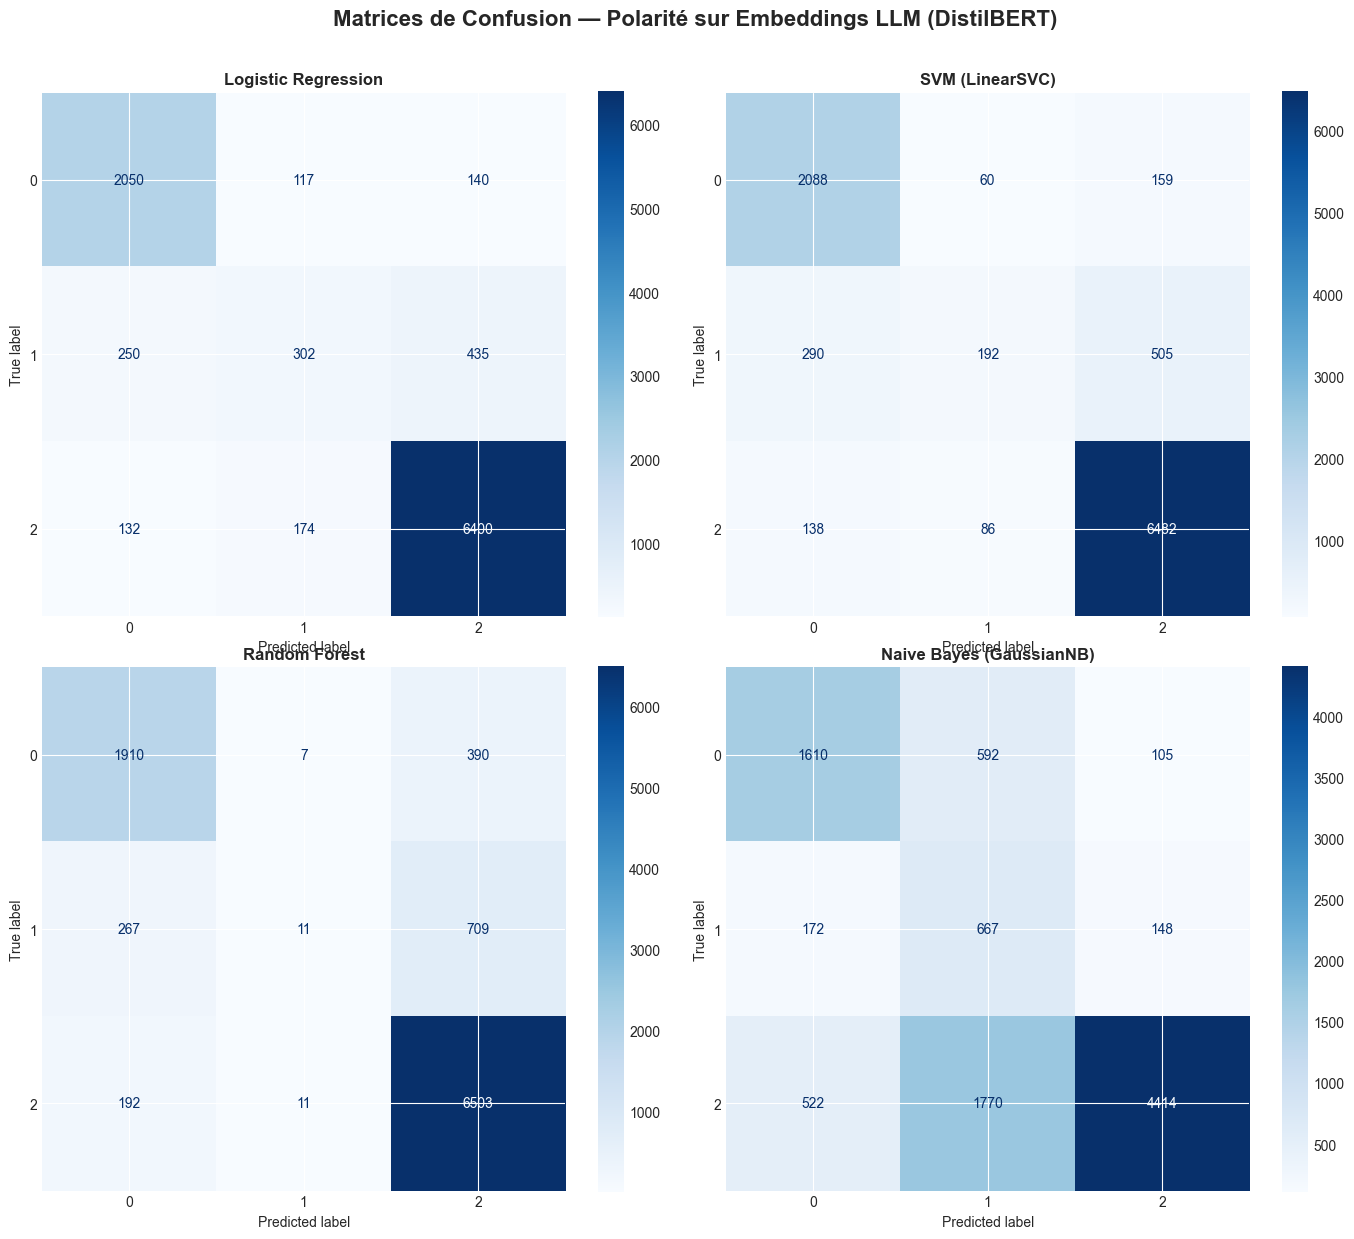

Figure sauvegardée : outputs/figures/confusion_matrices_llm_polarity.png


In [10]:
import os

all_results = [results_lr, results_svm, results_rf, results_nb]

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle('Matrices de Confusion — Polarité sur Embeddings LLM (DistilBERT)', 
             fontsize=16, fontweight='bold', y=1.02)

for ax, result in zip(axes.flat, all_results):
    plot_confusion_matrix(y_test_pol, result['y_pred'], result['model_name'], ax=ax)

plt.tight_layout()
os.makedirs('../../outputs/figures', exist_ok=True)
plt.savefig('../../outputs/figures/confusion_matrices_llm_polarity.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure sauvegardée : outputs/figures/confusion_matrices_llm_polarity.png')

## 7. Tableau comparatif des 4 modèles

In [11]:
# Construire le tableau comparatif
comparison_data = []
for r in all_results:
    comparison_data.append({
        'Modèle': r['model_name'],
        'Accuracy': f"{r['accuracy']:.4f}",
        'Precision': f"{r['precision']:.4f}",
        'Recall': f"{r['recall']:.4f}",
        'F1-Score': f"{r['f1_score']:.4f}"
    })

df_comparison = pd.DataFrame(comparison_data)
df_comparison = df_comparison.set_index('Modèle')

print('\n' + '='*70)
print('  TABLEAU COMPARATIF — ML sur Embeddings LLM (DistilBERT)')
print('='*70)
display(df_comparison)

# Identifier le meilleur modèle
best_idx = np.argmax([r['f1_score'] for r in all_results])
best = all_results[best_idx]
print(f'\n🏆 Meilleur modèle : {best["model_name"]} (F1={best["f1_score"]:.4f})')


  TABLEAU COMPARATIF — ML sur Embeddings LLM (DistilBERT)


,Accuracy,Precision,Recall,F1-Score
Modèle,,,,
Logistic Regression,0.8752,0.8600,0.8752,0.8647
SVM (LinearSVC),0.8762,0.8558,0.8762,0.8560
Random Forest,0.8424,0.7971,0.8424,0.8002
Naive Bayes (GaussianNB),0.6691,0.8172,0.6691,0.7144



🏆 Meilleur modèle : Logistic Regression (F1=0.8647)


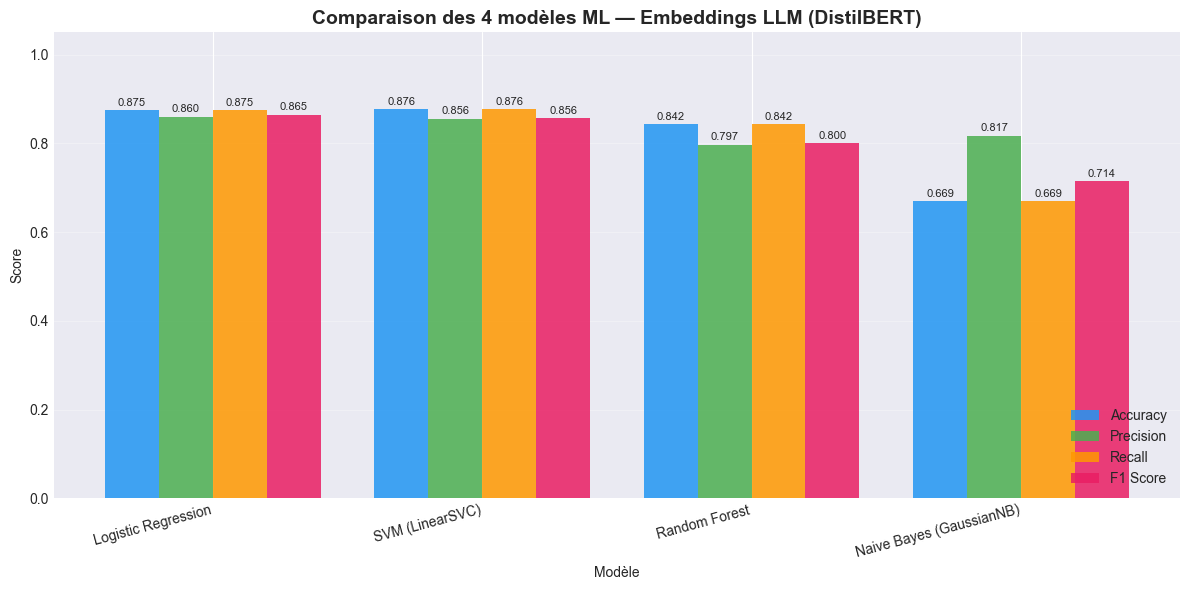

Figure sauvegardée : outputs/figures/comparison_ml_llm.png


In [12]:
# Visualisation comparative
metrics = ['accuracy', 'precision', 'recall', 'f1_score']
model_names = [r['model_name'] for r in all_results]

fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(model_names))
width = 0.2
colors = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63']

for i, (metric, color) in enumerate(zip(metrics, colors)):
    values = [r[metric] for r in all_results]
    bars = ax.bar(x + i * width, values, width, label=metric.replace('_', ' ').title(), 
                  color=color, alpha=0.85)
    # Annoter les barres
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8)

ax.set_xlabel('Modèle')
ax.set_ylabel('Score')
ax.set_title('Comparaison des 4 modèles ML — Embeddings LLM (DistilBERT)', 
             fontsize=14, fontweight='bold')
ax.set_xticks(x + 1.5 * width)
ax.set_xticklabels(model_names, rotation=15, ha='right')
ax.legend(loc='lower right')
ax.set_ylim(0, 1.05)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../../outputs/figures/comparison_ml_llm.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure sauvegardée : outputs/figures/comparison_ml_llm.png')

## 8. Tâche 2 : Prédiction du Score (1-5 étoiles)

On ré-entraîne le meilleur modèle (identifié sur la polarité) pour prédire le score exact (1-5).

In [13]:
# Entraîner les 4 modèles sur le score (1-5)
score_models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, solver='lbfgs'),
    'SVM (LinearSVC)': LinearSVC(max_iter=2000, random_state=RANDOM_STATE, dual='auto'),
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1),
    'Naive Bayes (GaussianNB)': GaussianNB()
}

score_results = []
for name, model in score_models.items():
    use_scaled = name != 'Random Forest'
    X_tr = X_train_scaled if use_scaled else X_train
    X_te = X_test_scaled if use_scaled else X_test
    result = train_and_evaluate(model, name, X_tr, X_te, y_train_score, y_test_score)
    score_results.append(result)


  Logistic Regression



Accuracy  : 0.6794
Precision : 0.6628
Recall    : 0.6794
F1-Score  : 0.6693

Classification Report :
              precision    recall  f1-score   support

           1       0.76      0.82      0.79      1578
           2       0.40      0.36      0.38       729
           3       0.45      0.38      0.41       987
           4       0.49      0.42      0.45      2006
           5       0.79      0.86      0.82      4700

    accuracy                           0.68     10000
   macro avg       0.58      0.57      0.57     10000
weighted avg       0.66      0.68      0.67     10000


  SVM (LinearSVC)



Accuracy  : 0.6795
Precision : 0.6461
Recall    : 0.6795
F1-Score  : 0.6535

Classification Report :
              precision    recall  f1-score   support

           1       0.72      0.87      0.79      1578
           2       0.41      0.24      0.30       729
           3       0.47      0.27      0.34       987
           4       0.49      0.39      0.43      2006
           5       0.76      0.90      0.82      4700

    accuracy                           0.68     10000
   macro avg       0.57      0.53      0.54     10000
weighted avg       0.65      0.68      0.65     10000


  Random Forest



Accuracy  : 0.6438
Precision : 0.5907
Recall    : 0.6438
F1-Score  : 0.5917

Classification Report :
              precision    recall  f1-score   support

           1       0.67      0.83      0.74      1578
           2       0.42      0.10      0.17       729
           3       0.40      0.13      0.20       987
           4       0.43      0.28      0.34      2006
           5       0.70      0.93      0.80      4700

    accuracy                           0.64     10000
   macro avg       0.52      0.46      0.45     10000
weighted avg       0.59      0.64      0.59     10000


  Naive Bayes (GaussianNB)

Accuracy  : 0.5237
Precision : 0.5913
Recall    : 0.5237
F1-Score  : 0.5436

Classification Report :
              precision    recall  f1-score   support

           1       0.60      0.69      0.64      1578
           2       0.26      0.42      0.32       729
           3       0.29      0.42      0.35       987
           4       0.34      0.39      0.36      2006
        

In [14]:
# Tableau comparatif — Score (1-5)
score_comparison = []
for r in score_results:
    score_comparison.append({
        'Modèle': r['model_name'],
        'Accuracy': f"{r['accuracy']:.4f}",
        'Precision': f"{r['precision']:.4f}",
        'Recall': f"{r['recall']:.4f}",
        'F1-Score': f"{r['f1_score']:.4f}"
    })

df_score = pd.DataFrame(score_comparison).set_index('Modèle')
print('\n' + '='*70)
print('  TABLEAU COMPARATIF — Score (1-5) sur Embeddings LLM')
print('='*70)
display(df_score)

best_score_idx = np.argmax([r['f1_score'] for r in score_results])
best_score = score_results[best_score_idx]
print(f'\n🏆 Meilleur modèle (score) : {best_score["model_name"]} (F1={best_score["f1_score"]:.4f})')


  TABLEAU COMPARATIF — Score (1-5) sur Embeddings LLM


,Accuracy,Precision,Recall,F1-Score
Modèle,,,,
Logistic Regression,0.6794,0.6628,0.6794,0.6693
SVM (LinearSVC),0.6795,0.6461,0.6795,0.6535
Random Forest,0.6438,0.5907,0.6438,0.5917
Naive Bayes (GaussianNB),0.5237,0.5913,0.5237,0.5436



🏆 Meilleur modèle (score) : Logistic Regression (F1=0.6693)


In [15]:
print('\n✅ Notebook SAE-117 terminé avec succès !')
print(f'   4 modèles ML entraînés sur embeddings LLM (DistilBERT)')
print(f'\n   Polarité (3 classes) :')
print(f'     Meilleur : {best["model_name"]} (F1={best["f1_score"]:.4f})')
print(f'\n   Score (1-5 étoiles) :')
print(f'     Meilleur : {best_score["model_name"]} (F1={best_score["f1_score"]:.4f})')


✅ Notebook SAE-117 terminé avec succès !
   4 modèles ML entraînés sur embeddings LLM (DistilBERT)

   Polarité (3 classes) :
     Meilleur : Logistic Regression (F1=0.8647)

   Score (1-5 étoiles) :
     Meilleur : Logistic Regression (F1=0.6693)
